# Import Library

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import cv2
import random
from datetime import datetime

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2

import warnings
warnings.filterwarnings('ignore')

# Load Data

In [6]:
base_dir = '../data_split' 
train_dir = f'{base_dir}/train'
validation_dir = f'{base_dir}/validation'
test_dir = f'{base_dir}/test'

print("="*50)
print("CEK FOLDER DATASET")
print("="*50)
print(f"Train folder exists: {os.path.exists(train_dir)}")
print(f"Validation folder exists: {os.path.exists(validation_dir)}")
print(f"Test folder exists: {os.path.exists(test_dir)}")

CEK FOLDER DATASET
Train folder exists: True
Validation folder exists: True
Test folder exists: True


# Data Augmentation

In [7]:
# Rescale data ke 1./255
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=[0.95, 1.05],
    horizontal_flip=True,
    fill_mode='constant',
    brightness_range=[0.98, 1.02],
)

validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Memuat Data

In [8]:
# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Validation generator
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Jumlah kelas: {train_generator.num_classes}")
print(f"📋 Indeks kelas: {train_generator.class_indices}")

Found 7500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.

✅ Jumlah kelas: 2
📋 Indeks kelas: {'Normal': 0, 'Tuberculosis': 1}


# Create MobileNetV2 Model

In [9]:
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = True
for layer in base_model.layers[:-50]:  
    layer.trainable = False

# Add custom layers on top (TETAP SAMA)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(l2=3e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(l2=3e-4))(x)
x = BatchNormalization()(x)
predictions = Dense(
    train_generator.num_classes, 
    activation='softmax', 
    kernel_regularizer=l2(l2=3e-4)
)(x)

model = Model(inputs=base_model.input, outputs=predictions)


# Summary MobileNetV2

In [10]:
# Tampilkan summary
print("\n" + "="*50)
print("ARSITEKTUR MODEL MOBILENETV2")
print("="*50)
model.summary()


ARSITEKTUR MODEL MOBILENETV2


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,620,610 (10.00 MB)

 Trainable params: 2,216,962 (8.46 MB)

 Non-trainable params: 403,648 (1.54 MB)

# Compile Model

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.00007, decay=1e-6, epsilon=1e-07, clipnorm=0.8),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Model berhasil dikompilasi")


✅ Model berhasil dikompilasi


# Callbacks

In [12]:
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.3, 
        patience=2, 
        min_lr=1e-8
    ),
    ModelCheckpoint(
        'best_model_mobilenetv2.h5', 
        monitor='val_accuracy', 
        save_best_only=True, 
        mode='max'
    ),
]

print("\n" + "="*50)
print("CALLBACKS")
print("="*50)
print("✅ ReduceLROnPlateau")
print("✅ ModelCheckpoint")


CALLBACKS
✅ ReduceLROnPlateau
✅ ModelCheckpoint


# Training Model

In [13]:
print("\n" + "="*50)
print("MULAI TRAINING MOBILENETV2")
print("="*50)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)



MULAI TRAINING MOBILENETV2
Epoch 1/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8404 - loss: 0.5137

234/234 ━━━━━━━━━━━━━━━━━━━━ 601s 2s/step - accuracy: 0.9258 - loss: 0.3468 - val_accuracy: 0.6243 - val_loss: 1.2813 - learning_rate: 7.0000e-05
Epoch 2/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 33s 138ms/step - accuracy: 1.0000 - loss: 0.1866 - val_accuracy: 0.6230 - val_loss: 1.2854 - learning_rate: 7.0000e-05
Epoch 3/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9895 - loss: 0.2121

234/234 ━━━━━━━━━━━━━━━━━━━━ 534s 2s/step - accuracy: 0.9892 - loss: 0.2105 - val_accuracy: 0.7398 - val_loss: 1.0441 - learning_rate: 7.0000e-05
Epoch 4/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 40s 164ms/step - accuracy: 1.0000 - loss: 0.1771 - val_accuracy: 0.7371 - val_loss: 1.0520 - learning_rate: 7.0000e-05
Epoch 5/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9938 - loss: 0.1928

234/234 ━━━━━━━━━━━━━━━━━━━━ 452s 2s/step - accuracy: 0.9934 - loss: 0.1917 - val_accuracy: 0.8913 - val_loss: 0.5522 - learning_rate: 7.0000e-05
Epoch 6/25
  1/234 ━━━━━━━━━━━━━━━━━━━━ 3:43 958ms/step - accuracy: 1.0000 - loss: 0.1729

234/234 ━━━━━━━━━━━━━━━━━━━━ 41s 171ms/step - accuracy: 1.0000 - loss: 0.1729 - val_accuracy: 0.8933 - val_loss: 0.5431 - learning_rate: 7.0000e-05
Epoch 7/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9962 - loss: 0.1825

234/234 ━━━━━━━━━━━━━━━━━━━━ 428s 2s/step - accuracy: 0.9946 - loss: 0.1842 - val_accuracy: 0.9864 - val_loss: 0.2073 - learning_rate: 7.0000e-05
Epoch 8/25
  1/234 ━━━━━━━━━━━━━━━━━━━━ 3:32 913ms/step - accuracy: 1.0000 - loss: 0.1695

234/234 ━━━━━━━━━━━━━━━━━━━━ 30s 125ms/step - accuracy: 1.0000 - loss: 0.1695 - val_accuracy: 0.9885 - val_loss: 0.2017 - learning_rate: 7.0000e-05
Epoch 9/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9969 - loss: 0.1770

234/234 ━━━━━━━━━━━━━━━━━━━━ 440s 2s/step - accuracy: 0.9963 - loss: 0.1777 - val_accuracy: 1.0000 - val_loss: 0.1656 - learning_rate: 7.0000e-05
Epoch 10/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 39s 162ms/step - accuracy: 1.0000 - loss: 0.1648 - val_accuracy: 1.0000 - val_loss: 0.1654 - learning_rate: 7.0000e-05
Epoch 11/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 396s 2s/step - accuracy: 0.9964 - loss: 0.1726 - val_accuracy: 0.9986 - val_loss: 0.1622 - learning_rate: 7.0000e-05
Epoch 12/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 32s 132ms/step - accuracy: 1.0000 - loss: 0.1592 - val_accuracy: 0.9986 - val_loss: 0.1623 - learning_rate: 7.0000e-05
Epoch 13/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.9976 - loss: 0.1647 - val_accuracy: 0.9993 - val_loss: 0.1563 - learning_rate: 7.0000e-05
Epoch 14/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - accuracy: 1.0000 - loss: 0.1543 - val_accuracy: 0.9993 - val_loss: 0.1563 - learning_rate: 7.0000e-05
Epoch 15/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - ac

# Plot Training History (LANGSUNG SETELAH TRAINING)

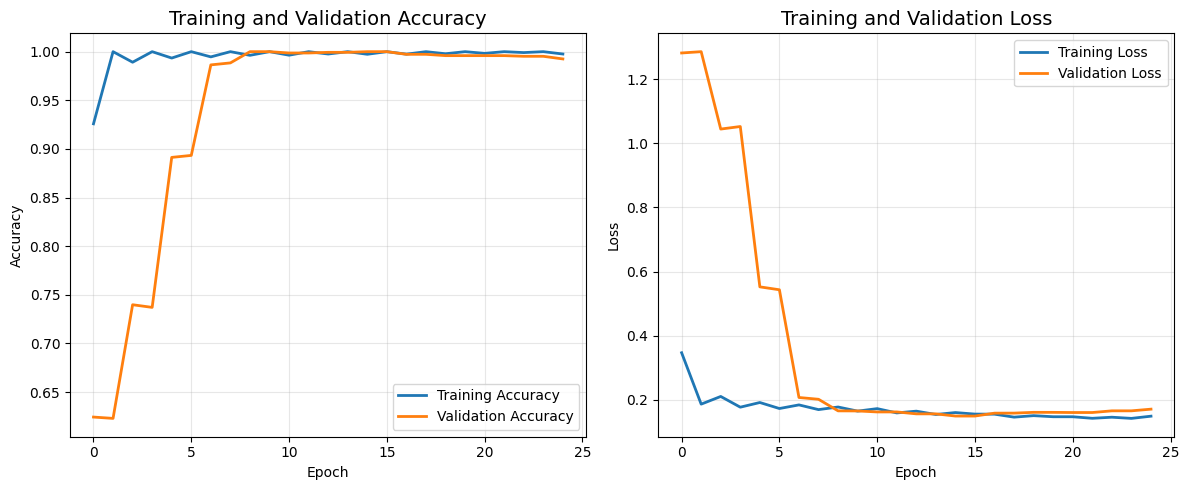

In [14]:
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_mobilenetv2.png', dpi=300)
plt.show()

# Cek Output Model

In [15]:
print("\n" + "="*50)
print("INFORMASI MODEL")
print("="*50)
print("Number of classes in test_generator:", test_generator.num_classes)
print("Number of classes in model output:", model.output_shape)


INFORMASI MODEL
Number of classes in test_generator: 2
Number of classes in model output: (None, 2)


# Load Model Terbaik

In [16]:
model.load_weights('best_model_mobilenetv2.h5')
print("✅ Model terbaik dimuat dari: best_model_mobilenetv2.h5")

✅ Model terbaik dimuat dari: best_model_mobilenetv2.h5


# EVALUASI MODEL PADA DATA TEST

In [17]:
print("\n" + "="*50)
print("EVALUASI MODEL PADA DATA TEST")
print("="*50)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")



EVALUASI MODEL PADA DATA TEST
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 908ms/step - accuracy: 0.9990 - loss: 0.1658
Test accuracy: 0.9990
Test Loss: 0.1658


# PREDIKSI PADA DATA TEST

In [18]:
# Prediksi
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Ambil label sebenarnya
y_true = test_generator.classes


32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 589ms/step


# CLASSIFICATION REPORT

In [19]:
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=list(test_generator.class_indices.keys())
))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       500
Tuberculosis       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



# CONFUSION MATRIX

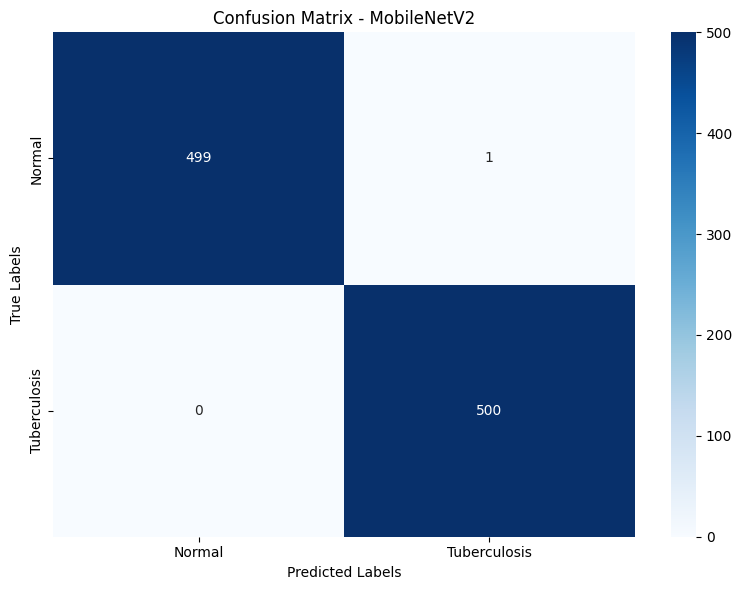

In [20]:
conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - MobileNetV2')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# SIMPAN MODEL FINAL

In [21]:
print("\n" + "="*50)
print("MENYIMPAN MODEL")
print("="*50)

# Simpan model final
model.save('mobilenetv2_tb_final.h5')
print("✅ Model final disimpan: mobilenetv2_tb_final.h5")


MENYIMPAN MODEL
✅ Model final disimpan: mobilenetv2_tb_final.h5


# RINGKASAN HASIL

In [22]:
print("\n" + "="*60)
print("🎉 RINGKASAN HASIL TRAINING MOBILENETV2 🎉")
print("="*60)

print(f"""
📊 HASIL EVALUASI:
   Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)
   Test Loss     : {test_loss:.4f}

📁 FILE YANG TERSIMPAN:
   1. best_model_mobilenetv2.h5   (model terbaik dari training)
   2. mobilenetv2_tb_final.h5     (model final)
   3. training_history.png         (grafik training)
   4. confusion_matrix.png         (matriks confusion)
""")

print("="*60)
print("✅ TRAINING MOBILENETV2 SELESAI!")
print("="*60)


🎉 RINGKASAN HASIL TRAINING MOBILENETV2 🎉

📊 HASIL EVALUASI:
   Test Accuracy : 0.9990 (99.90%)
   Test Loss     : 0.1658

📁 FILE YANG TERSIMPAN:
   1. best_model_mobilenetv2.h5   (model terbaik dari training)
   2. mobilenetv2_tb_final.h5     (model final)
   3. training_history.png         (grafik training)
   4. confusion_matrix.png         (matriks confusion)

✅ TRAINING MOBILENETV2 SELESAI!
